In [2]:
import os
import cv2
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

Analisando pastas...

=== RESUMO DOS FRAMES ===
Total de vídeos analisados: 800
Mínimo de frames: 15
Máximo de frames: 133
Média: 67.1
Mediana: 66.0
75% dos vídeos têm até: 76.0 frames
Tempo de contagem de 53713 frames = 0.0138 minutos


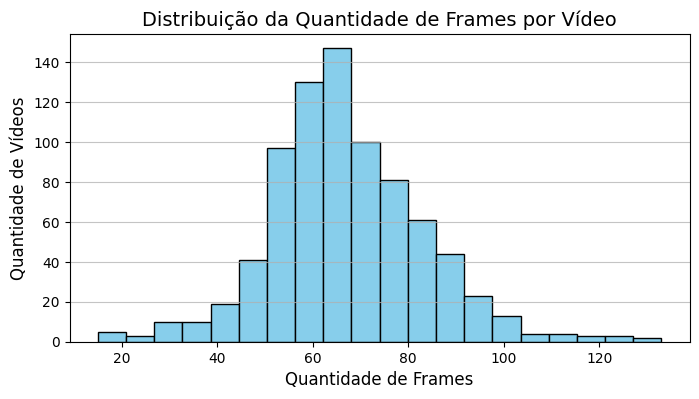

In [3]:
BASE_PATH = r'..\data\pre_processado\yolo11_resultado_teste_rede_14_05_total'

quant_frames = []
classes = []

print("Analisando pastas...")

inicio = time.time()

#classe para organizar o nome das classes e também contar a médida de frames para aplicar na variavel MAX_FRAMES
for folder_name in os.listdir(BASE_PATH):
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    if os.path.isdir(folder_path):
        num_frames = 0
        todos_os_itens = os.listdir(folder_path)
        for f in todos_os_itens:
            caminho_completo = os.path.join(folder_path, f)
            if os.path.isfile(caminho_completo):
                num_frames += 1  # Soma 1 para cada arquivo de imagem encontrado
        quant_frames.append(num_frames)
        nome_classe = folder_name.split('_')[0]
        classes.append(nome_classe)


fim = time.time()
tempo = (fim-inicio)/60


# transforma em array numpy para facilitar as estatísticas
quant_frames = np.array(quant_frames)

#dados 
print("\n=== RESUMO DOS FRAMES ===")
print(f"Total de vídeos analisados: {len(quant_frames)}")
print(f"Mínimo de frames: {np.min(quant_frames)}")
print(f"Máximo de frames: {np.max(quant_frames)}")
print(f"Média: {np.mean(quant_frames):.1f}")
print(f"Mediana: {np.median(quant_frames):.1f}")
print(f"75% dos vídeos têm até: {np.percentile(quant_frames, 75):.1f} frames")
print(f"Tempo de contagem de {np.sum(quant_frames)} frames = {tempo:.4f} minutos")

#grafico
plt.figure(figsize=(8, 4))
plt.hist(quant_frames, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuição da Quantidade de Frames por Vídeo', fontsize=14)
plt.xlabel('Quantidade de Frames', fontsize=12)
plt.ylabel('Quantidade de Vídeos', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()



In [ ]:
class GeradorDeVideos(tf.keras.utils.Sequence):
    def __init__(self, caminhos_pastas, rotulos, classes_lista, batch_size, max_frames, img_size):
        self.caminhos = caminhos_pastas
        self.rotulos = rotulos
        self.classes_lista = classes_lista
        self.batch_size = batch_size
        self.max_frames = max_frames
        self.img_size = img_size

    def __len__(self):
        # Diz ao Keras quantos lotes existem por Época
        return int(np.ceil(len(self.caminhos) / float(self.batch_size)))

    def __getitem__(self, idx):
        # Pega apenas os caminhos do Lote atual (ex: 8 vídeos de cada vez)
        lote_caminhos = self.caminhos[idx * self.batch_size : (idx + 1) * self.batch_size]
        lote_rotulos = self.rotulos[idx * self.batch_size : (idx + 1) * self.batch_size]

        X_batch = []
        y_batch = []

        for i, folder_path in enumerate(lote_caminhos):
            # Carrega os frames DESTE vídeo específico
            frames = carregar_frames_pasta(folder_path, self.max_frames, self.img_size)
            X_batch.append(frames)
            
            # Converte o nome da classe para o índice correto (ex: 'acontecer' -> 0)
            idx_classe = self.classes_lista.index(lote_rotulos[i])
            y_batch.append(idx_classe)

        # Garante o float32 para salvar memória (ESTA É A PARTE QUE RESOLVE O SEU ERRO)
        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = to_categorical(y_batch, num_classes=len(self.classes_lista))

        return X_batch, y_batch

In [ ]:
def carregar_frames_pasta(folder_path, n_frames, img_size):
    frames = []

    #ordena para garantir a sequencia dos arquivos de acordo com os nomes
    imagens = []
    todos_os_itens = os.listdir(folder_path)

    
    for item in todos_os_itens:
        caminho_completo = os.path.join(folder_path, item)
        if os.path.isfile(caminho_completo):
            imagens.append(item)
    imagens.sort()

    
    for img_file in imagens:
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      #conversao de BGR para RGB
            img = (img / 255.0).astype(np.float32)                               # Normalização entre 0 e 1
            frames.append(img)
            

    # uniformizar a quantidade de frames
    if len(frames) == 0:
        return np.zeros((n_frames, img_size, img_size, 3))  #se caso a pasta tiver vazio ele preenche com zeros

    if len(frames) > n_frames:                              #se tiver muitos frames, é pego os frames centrais
        inicio = (len(frames) - n_frames) // 2
        frames = frames[inicio : inicio + n_frames]
    elif len(frames) < n_frames:                            #se tiver menos frames, repete o ultimo até o fim do vetor
        ultimo_frame = frames[-1]
        while len(frames) < n_frames:
            frames.append(ultimo_frame)
            
    return np.array(frames)

In [5]:
#inicialização
print("TensorFlow version:", tf.__version__)
print("GPU disponível:" if tf.config.list_physical_devices('GPU') else "Usando CPU")


#configurações do modelo de treino
IMG_SIZE = 224                                  #resolucao das imagens
MAX_FRAMES = round(np.mean(quant_frames))     # quantidade fixa de frames que a LSTM vai processar de acordo com a média de frames
BATCH_SIZE = 8                                  #sequencia de amostras 
EPOCHS = 10                                      #numero de vezes que o algoritmo percorre o conjunto

TensorFlow version: 2.21.0
Usando CPU


In [6]:
X = []
y_labels = []
folders = []


todos_os_itens = os.listdir(BASE_PATH)
for item in todos_os_itens:
    caminho_completo = os.path.join(BASE_PATH, item)
    if os.path.isdir(caminho_completo):
        folders.append(item)


print(f"Processando {len(folders)} pastas...")

for folder_name in folders:
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    # Extrai o nome da classe (ex: 'acontecer_1' -> 'acontecer')
    class_name = folder_name.rsplit('_', 1)[0]
    
    video_sequence = carregar_frames_pasta(folder_path, MAX_FRAMES, IMG_SIZE)
    X.append(video_sequence)
    y_labels.append(class_name)

X = np.array(X)
print("Formato final de X:", X.shape) # Esperado: (N, 20, 224, 224, 3)

Processando 800 pastas...


MemoryError: Unable to allocate 76.9 MiB for an array with shape (67, 224, 224, 3) and data type float64

In [ ]:
encoder = LabelEncoder()                                #codificacao para o entendimento da rede - de nomes para números
y_integers = encoder.fit_transform(y_labels)
class_names = encoder.classes_                          #nomes das classes 
y = to_categorical(y_integers)                          #transforma os números em vetores binários

# treino (80%) e teste (20%)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_integers)

print(f"Classes: {class_names}")
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

In [ ]:
#definições da rede neural

n_classes = len(class_names)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))       #largura, largura, canais de cor
base_model.trainable = False                                                                            # congela os pesos da ResNet para não ter alterações ao longo do processo


#cada camada alimenta a próxima em linha reta
model = Sequential([
    TimeDistributed(base_model, input_shape=(MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)),       #aplicaão da resnet em cada imagem, funciona como um loop
    TimeDistributed(GlobalAveragePooling2D()),                                          #diminui o tamanho dos dados gerados de matriz bidimensionais para matriz
    
    LSTM(64, return_sequences=False),          # analise da sequencia de frames, entregando uma resposta apenas no final
    Dropout(0.5),                              #camada de segurança contra o overfitting (quando o modelo decora o treino mas erra no teste)
    Dense(64, activation='relu'),              #camada intermediária totalmente conectada com 64 neurônios     ********** PESQUISAR***********
    Dense(n_classes, activation='softmax')     #o mesmo n de neurônios que a quantidade de classes que você possui e softmax transforma a saída final em probabilidades que somam 100% 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])      #algoritmo que ajustará os pesos da LSTM e das camadas densas
model.summary() 

In [ ]:
#inicio do processamento da rede - treinamento
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test),   #a cada final de epoca o modelo interrompe o treino temporariamente e usa os dados de teste 20%
    epochs=EPOCHS,                      #repeticao
    batch_size=BATCH_SIZE,               #o modelo precessa nm videos de uma vez na GPU
    callbacks=[early_stop]
)

model.save('modelo_lstm_final.h5')

In [ ]:

def avaliacao_modelo(model, X_test, y_test, history, classes):
    # 1. Gráficos de Treino e Validação
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title('Acurácia Geral')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino (Perda)')
    plt.plot(history.history['val_loss'], label='Validação (Perda)')
    plt.title('Perda (Loss)')
    plt.legend()
    plt.savefig('acuracia_loss.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Gerar Previsões 
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # 3. Matriz de Confusão
    indices_classes = range(len(classes))
    cm = confusion_matrix(y_true, y_pred, labels=indices_classes)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('O que SAIU', fontsize=12)
    plt.ylabel('O que era ESPERADO', fontsize=12)
    plt.title('Matriz de Confusão', fontsize=14)
    plt.savefig('matriz_de_confusao.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 4. RESULTADO ENXUTO POR CLASSE
    print("\n" + "="*50)
    print("RESULTADOS POR CLASSE")
    print("="*50)
    
    for i, nome_classe_real in enumerate(classes):
        total_real = cm[i].sum() 
        acertos = cm[i][i]
        
        if total_real > 0:
            acuracia = (acertos / total_real)
            print(f"\nEsperado: {nome_classe_real.upper()} | Acurácia: {acuracia:.2f}")
            
            # Lista apenas o que saiu, sem contar totais
            for j, nome_classe_prevista in enumerate(classes):
                if cm[i][j] > 0:
                    status = "✅ Acerto" if i == j else "❌ Erro"
                    print(f" -> Saiu: {nome_classe_prevista} ({status})")
        else:
            print(f"\nEsperado: {nome_classe_real.upper()} | Acurácia: N/A (Sem dados no teste)")

avaliacao_modelo(model, X_test, y_test, history, class_names)

NameError: name 'model' is not defined